3.Import the required packages with their customary aliases as follows:
-

In [1]:
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns

4.Using the pandas `read_csv()` method, read the GDP dataset into your notebook as a DataFrame called `gdp_df`. Take a look at the first few and last few rows to familiarize yourself with what is contained in this dataset.
-

In [2]:
gdp_df = pd.read_csv('../data/gdp_percapita.csv')
gdp_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN


In [3]:
gdp_df.tail()

,Country or Area,Year,Value,Value Footnotes
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN
8464,Zimbabwe,1990,6082.842451,NaN


5.How many rows and columns are in `gdp_df`? What are the data types of each column?
-
----
    8465, 4
    'Country or Area', 'Year', 'Value', 'Value Footnotes'

In [4]:
gdp_df.shape

(8465, 4)

In [5]:
gdp_df.columns

Index(['Country or Area', 'Year', 'Value', 'Value Footnotes'], dtype='object')

6.Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'GDP_Per_Capita'.
-

In [6]:
gdp_df = gdp_df.drop(columns = ['Value Footnotes'])
gdp_df = gdp_df.rename(columns = {'Country or Area':'Country','Year':'Year','Value':'GDP_Per_Capita'})             

7.How many countries have data for all years? Which countries are missing many years of data? Look at the number of observations per year. What do you notice? 
-

In [94]:
all_years = gdp_df['Year'].nunique()
country_counts = gdp_df.groupby('Country')['Year'].nunique()
complete_countries = country_counts[country_counts == all_years]
print(f"{len(complete_countries)} countries have data for all years")

226 countries have data for all years


These are the countries missing data
-

In [95]:
print(country_counts.sort_values().head(10))

Country
Djibouti                     12
Sint Maarten (Dutch part)    16
Kosovo                       17
Faroe Islands                17
Turks and Caicos Islands     18
Cayman Islands               18
Virgin Islands (US)          21
Afghanistan                  24
CuraÃ§ao                     25
San Marino                   27
Name: Year, dtype: int64


8.In this question, you're going to create some plots to show the distribution of GDP per capita for the year 2020. Go to the Python Graph Gallery (https://www.python-graph-gallery.com/) and look at the different types of plots under the Distribution section. Create a histogram, a density plot, a boxplot, and a violin plot. What do you notice when you look at these plots? How do the plots compare and what information can you get out of one type that you can't necessarily get out of the others?
-

In [8]:
gdp2020 = gdp_df.query('Year == 2020')
gdp2020

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
28,Africa Eastern and Southern,2020,3978.931395
63,Africa Western and Central,2020,5687.849988
98,Albania,2020,15659.588696
133,Algeria,2020,14194.155748
...,...,...,...
8310,Virgin Islands (US),2020,45055.782930
8333,West Bank and Gaza,2020,5423.682547
8364,World,2020,18803.068884
8399,Zambia,2020,3391.595412


Histogram
-

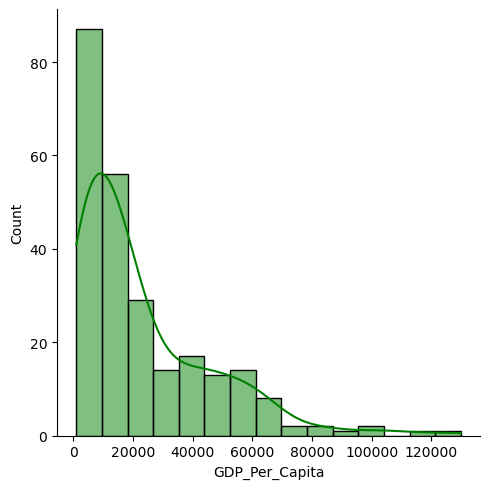

In [105]:
sns.displot( data=gdp2020['GDP_Per_Capita'], kde=True, color = 'green' )

Density Plot
-

<Axes: xlabel='GDP_Per_Capita', ylabel='Density'>

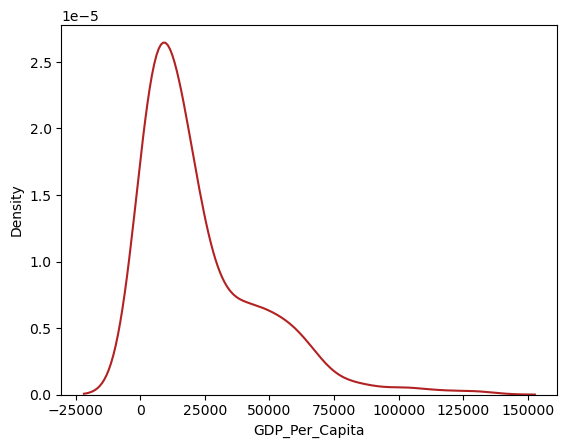

In [150]:
sns.kdeplot(gdp2020['GDP_Per_Capita'],color = 'firebrick')

Boxplot
-

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

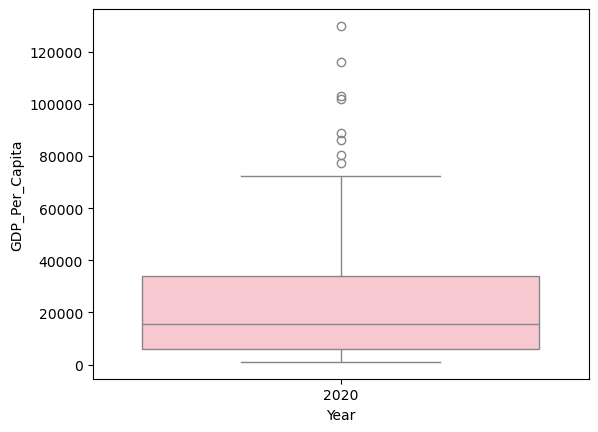

In [106]:
sns.boxplot( x=gdp2020["Year"], y=gdp2020['GDP_Per_Capita'], color = 'pink' )

Violin Plot
-

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

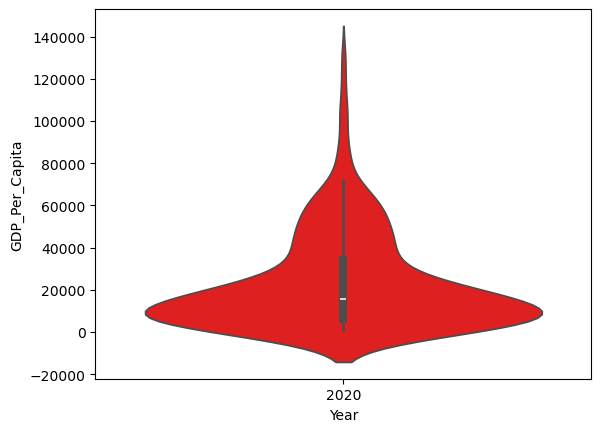

In [107]:
sns.violinplot( x=gdp2020["Year"], y=gdp2020['GDP_Per_Capita'], color = 'red' )

9.What was the median GDP per capita value in 2020?
-

In [13]:
gdp2020['GDP_Per_Capita'].median()

15399.308958012449

10. For this question, you're going to create some visualizations to compare GDP per capita values for the years 1990, 2000, 2010, and 2020. Start by subsetting your data to just these 4 years into a new DataFrame named gdp_decades. Using this, create the following 4 plots:
	* A boxplot
	* A barplot (check out the Barplot with Seaborn section: https://www.python-graph-gallery.com/barplot/#Seaborn)
	* A scatterplot
	* A scatterplot with a trend line overlaid (see this regplot example: https://www.python-graph-gallery.com/42-custom-linear-regression-fit-seaborn)


In [14]:
gdp_decades = gdp_df[gdp_df['Year'].isin([1990,2000,2010,2020])]

Boxplot
-

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

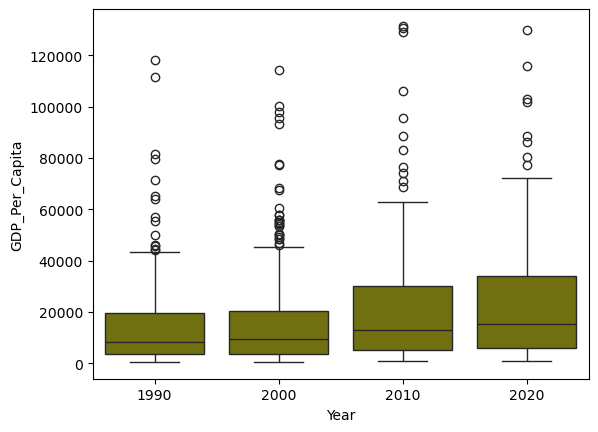

In [130]:
sns.boxplot( x=gdp_decades['Year'], y=gdp_decades['GDP_Per_Capita'], color ='olive' )

Barplot
-

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

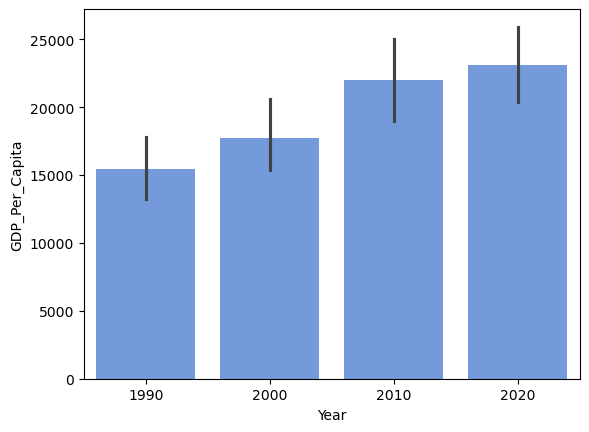

In [149]:
sns.barplot(x='Year', y='GDP_Per_Capita', data=gdp_decades, color = 'cornflowerblue')

Scatterplot
-

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

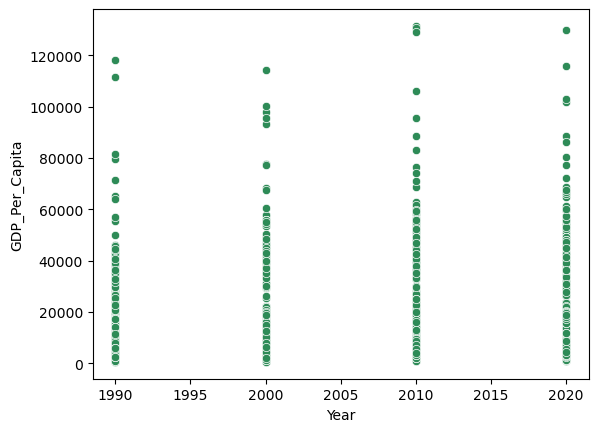

In [151]:
sns.scatterplot(x=gdp_decades['Year'], y=gdp_decades['GDP_Per_Capita'], color = 'seagreen')

Scatterplot with a trend line overlaid
-

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

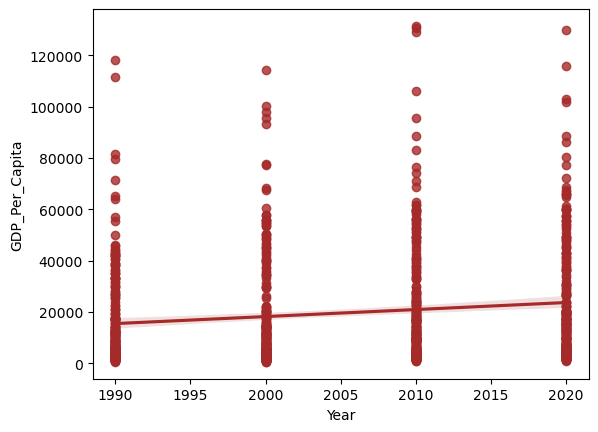

In [147]:
sns.regplot(x=gdp_decades['Year'], y=gdp_decades['GDP_Per_Capita'], color = 'brown')

Comment on what you observe has happened to GDP values over time and the relative strengths and weaknesses of each type of plot.

11.Which country was the first to have a GDP per capita greater than $100,000?
--
United Arab Emirates & Brunei Darussalam

In [19]:
above_100k = gdp_df[gdp_df['GDP_Per_Capita'] > 100000]
above_100k = above_100k.sort_values('Year')
above_100k.head()

,Country,Year,GDP_Per_Capita
8062,United Arab Emirates,1990,111377.046890
1037,Brunei Darussalam,1990,118163.683370
8061,United Arab Emirates,1991,106266.193694
1036,Brunei Darussalam,1991,118220.683595
8060,United Arab Emirates,1992,104206.754891


12.Which country had the highest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.
-

In [20]:
most_gdp2020 = gdp_df[gdp_df['Year'] == 2020]
no1_country = most_gdp2020.loc[gdp2020['GDP_Per_Capita'].idxmax(), 'Country']
print(no1_country)

Luxembourg


<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

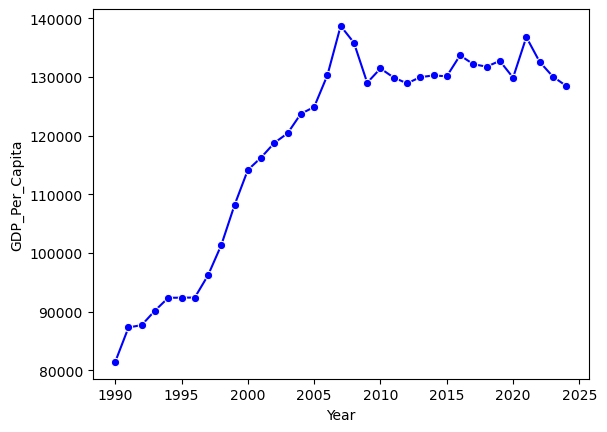

In [102]:
country_df = gdp_df[gdp_df['Country'] == no1_country]
sns.lineplot(data = country_df, x = 'Year', y = 'GDP_Per_Capita', marker = 'o', color = 'blue')

13.Which country had the lowest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset. **Bonus question:** Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?
-

In [22]:
least_gdp2020 = gdp_df[gdp_df['Year'] == 2020]
leastGDP_country = least_gdp2020.loc[gdp2020['GDP_Per_Capita'].idxmin(), 'Country']
print(leastGDP_country)

Burundi


<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

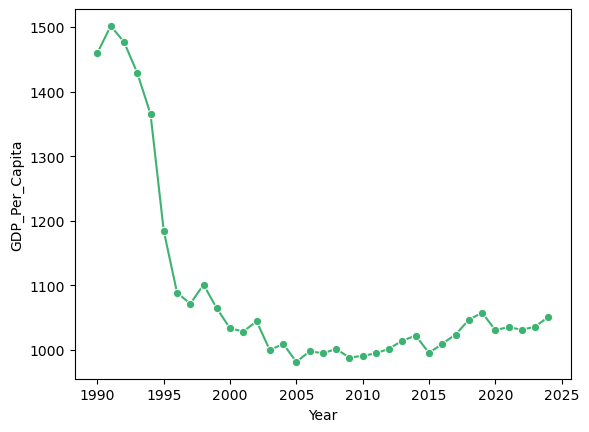

In [155]:
least_gdp2020df = gdp_df[gdp_df['Country'] == leastGDP_country]
sns.lineplot(data = least_gdp2020df,
             x = 'Year',
             y = 'GDP_Per_Capita',
             marker = 'o',
             color = 'mediumseagreen')

14.Read in the internet use dataset into a DataFrame named `internet_df`. You will likely get errors when doing this. Check the arguments for the read_csv function to find ones that can help correct the errors (https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) Once you are able to read it in, take per a look at the top and bottom few rows to make sure that it has been read in correctly. Also, check the datatypes of the columns.
-

In [24]:
internet_df = pd.read_csv('../data/internet_use.csv',
                         on_bad_lines='skip',
                         skipfooter=297,
                         engine='python'
)
internet_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.60,1
1,Afghanistan,2018,16.80,2
2,Afghanistan,2017,13.50,3
3,Afghanistan,2016,11.00,4
4,Afghanistan,2015,8.26,4


In [25]:
internet_df.tail()

,Country or Area,Year,Value,Value Footnotes
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN
6082,Zimbabwe,1990,0.000000,NaN


In [26]:
internet_df.columns

Index(['Country or Area', 'Year', 'Value', 'Value Footnotes'], dtype='object')

15.Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'Internet_Users_Pct'.
-

In [27]:
internet_df = internet_df.drop(columns = ['Value Footnotes']) 
internet_df = internet_df.rename(columns = {'Country or Area':'Country','Year':'Year','Value':'Internet_Users_Pct'}) 

16.Look at the number of observations in this dataset per year. What do you notice?
-

In [156]:
internet_df['Year'].value_counts().sort_index()

Year
1990    226
1991     39
1992     50
1993     66
1994     92
1995    141
1996    177
1997    188
1998    195
1999    207
2000    210
2001    212
2002    214
2003    208
2004    210
2005    212
2006    212
2007    217
2008    214
2009    214
2010    209
2011    214
2012    209
2013    203
2014    204
2015    203
2016    206
2017    205
2018    174
2019    185
2020    186
2021    186
2022    184
2023     11
Name: count, dtype: int64

17.What is the first year to have a non-zero internet users percentage value?
-
1990

In [29]:
nonzero = internet_df[internet_df['Internet_Users_Pct']>0]
nonzero['Year'].min()

1990

18.How does the distribution of internet users percent differ for 2000 and 2014?
-

<Axes: xlabel='Year', ylabel='Internet_Users_Pct'>

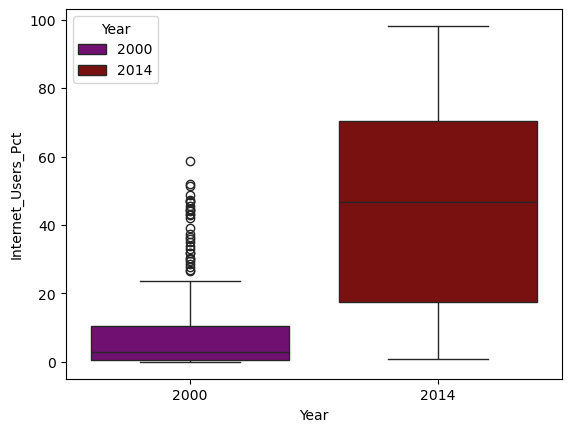

In [145]:
net_00_14 = internet_df [
    internet_df['Year'].isin ([2000, 2014])
    ]           
sns.boxplot( data = net_00_14,
             x='Year',
             y='Internet_Users_Pct',
              hue='Year',
    palette={
        2000: 'purple',
        2014: 'darkred'
    },
    legend=True
             )

19.For how many countries was the percentage of internet users below 5% in 2014?
-

In [31]:
below5_2014 = internet_df[
    (internet_df['Internet_Users_Pct']<5) &
    (internet_df['Year'] == 2014)
    ]
len(below5_2014)

10

20.Merge the two DataFrames to one. Do this in a way that keeps **all rows** from each of the two DataFrames. Call the new DataFrame `gdp_and_internet_use`. Look at the first and last few rows to confirm that it merged correctly.
-

In [49]:
gdp_and_internet_use = pd.merge(gdp_df,
                                internet_df,
                                on=['Country','Year'],
                                how = 'outer'
                               )
gdp_and_internet_use

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,Afghanistan,1990,NaN,0.000000
1,Afghanistan,2000,1617.826475,NaN
2,Afghanistan,2001,1454.110782,0.004723
3,Afghanistan,2002,1774.308743,0.004561
4,Afghanistan,2003,1815.928200,0.087891
...,...,...,...,...
9775,Zimbabwe,2020,4527.719881,29.298600
9776,Zimbabwe,2021,4827.088694,32.461600
9777,Zimbabwe,2022,5036.761361,32.561500
9778,Zimbabwe,2023,5218.022665,NaN


21.Find the three countries with the highest internet users percentage in 2014. Use a seaborn FacetGrid (https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) to compare how the GDP per capita has changed over time for these three countries. What do you notice?
-

Iceland, Falkland (Malvinas) Islands, Bermuda 
######
No per capita listed for Falkland (Malvinas) Islands

In [47]:
gdp_netuse2014 = gdp_and_internet_use[gdp_and_internet_use['Year'] == 2014]
gdp_netuse2014.sort_values('Internet_Users_Pct',ascending = False).head(3)

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
4115,Iceland,2014,59133.270146,98.158
2975,Falkland (Malvinas) Islands,2014,NaN,97.600
880,Bermuda,2014,93042.273305,96.800


In [64]:
gdp_top3_2014 = gdp_netuse2014.sort_values('Internet_Users_Pct',ascending = False).head(3)
gdp_top3_2014

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
4115,Iceland,2014,59133.270146,98.158
2975,Falkland (Malvinas) Islands,2014,NaN,97.600
880,Bermuda,2014,93042.273305,96.800


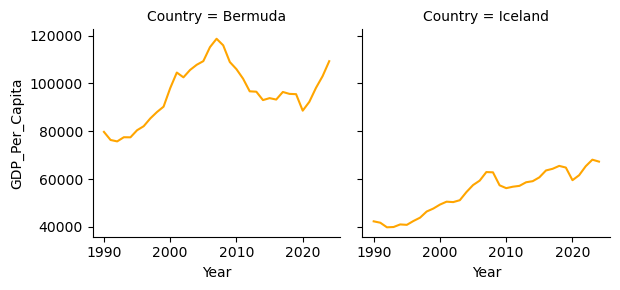

In [73]:
top3_countries = gdp_top3_2014['Country']
facet_data = gdp_df[gdp_df['Country'].isin(top3_countries)]
g = sns.FacetGrid(facet_data, col ='Country', col_wrap=3)
g.map_dataframe(sns.lineplot,
                x='Year',
                y= 'GDP_Per_Capita',
               color= 'orange'
               )

22.Subset `gdp_and_internet_use` to just the year 2014. Save this as a new dataframe named `gdp_and_internet_use_2014`.
-

In [66]:
gdp_and_internet_use_2014 = gdp_and_internet_use[gdp_and_internet_use['Year'] == 2014]
gdp_and_internet_use_2014

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
15,Afghanistan,2014,3017.942544,7.0000
49,Africa Eastern and Southern,2014,4185.238411,NaN
84,Africa Western and Central,2014,6174.703316,NaN
119,Albania,2014,12718.284760,54.3000
154,Algeria,2014,15073.762940,29.5000
...,...,...,...,...
9638,West Bank and Gaza,2014,5990.426615,NaN
9673,World,2014,17492.498902,NaN
9703,Yemen,2014,NaN,22.5500
9734,Zambia,2014,3585.577485,6.5000


23.Create a plot which compares Internet Users Percentage and GDP per Capita for the year 2014. What do you notice from this plot? If you see any unusual points, investigate them.
-

<Axes: xlabel='GDP_Per_Capita', ylabel='Internet_Users_Pct'>

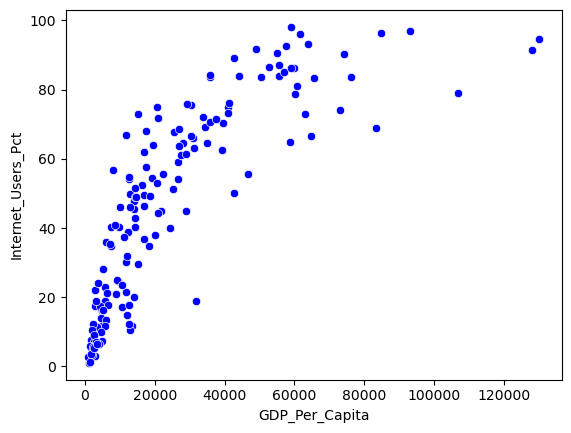

In [117]:
sns.scatterplot(
    data=gdp_and_internet_use_2014,
    x='GDP_Per_Capita',
    y='Internet_Users_Pct',
    color = 'blue'
)

24.**Stretch Question:** Use the `qcut` function from pandas (https://pandas.pydata.org/docs/reference/api/pandas.qcut.html) to divide countries in `gdp_per_capita_2014` into three groups based on their GDP per capita values. Label these groups as "Low", "Medium", and "High". Put these labels in a new column, named "GDP_group".
-

In [122]:
gdp_and_internet_use_2014 = gdp_and_internet_use[
    gdp_and_internet_use['Year'] == 2014
].copy()

In [125]:
gdp_and_internet_use_2014['GDP_group'] = pd.qcut(
    gdp_and_internet_use_2014['GDP_Per_Capita'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
gdp_and_internet_use_2014[['Country', 'GDP_Per_Capita', 'GDP_group']].head()

,Country,GDP_Per_Capita,GDP_group
15,Afghanistan,3017.942544,Low
49,Africa Eastern and Southern,4185.238411,Low
84,Africa Western and Central,6174.703316,Low
119,Albania,12718.284760,Medium
154,Algeria,15073.762940,Medium


25.**Stretch Question:** How does the median internet users percentage compare for the three gdp groups?
-

In [129]:
median_internet = gdp_and_internet_use_2014.groupby(
    'GDP_group',
    observed=False
)['Internet_Users_Pct'].median()
print(median_internet)

GDP_group
Low       11.6000
Medium    44.8033
High      75.3355
Name: Internet_Users_Pct, dtype: float64


<Axes: xlabel='GDP_group', ylabel='Internet_Users_Pct'>

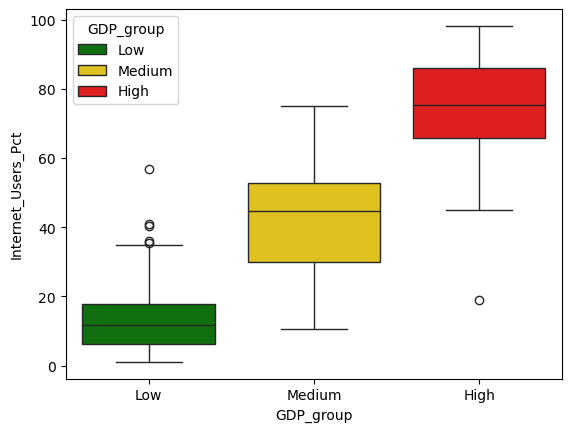

In [134]:
sns.boxplot(
    data=gdp_and_internet_use_2014,
    x='GDP_group',
    y='Internet_Users_Pct',
    hue='GDP_group',
    palette={
        'Low': 'green',
        'Medium': 'gold',
        'High': 'red'
    }
)

##### Bonus exercise:
   Download another data set from the UN data (http://data.un.org/Explorer.aspx) to merge with your data and explore.